In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris
from IPython.display import display

# ── Global style ─────────────────────────────────────────────────
PALETTE = {"Setosa": "#3B8C6E", "Versicolor": "#6C7FC4", "Virginica": "#E07B54"}
BG      = "#FAFAF8"
GRID    = "#E8E6E0"
TEXT    = "#2C2C2A"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    GRID,
    "axes.grid":         True,
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelcolor":   TEXT,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "text.color":        TEXT,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.titlepad":     14,
    "axes.labelpad":     8,
})


In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target
df["Species"] = df["Species"].map({0:"Setosa", 1:"Versicolor", 2:"Virginica"})

# Styled HTML table preview
styled = (df.head(10)
    .style
    .set_table_styles([{
        "selector": "thead th",
        "props": [("background-color","#2C2C2A"),("color","white"),("font-weight","600"),("padding","8px 14px"),("text-align","left")]
    },{
        "selector": "tbody td",
        "props": [("padding","7px 14px"),("border-bottom","1px solid #E8E6E0")]
    },{
        "selector": "tbody tr:hover",
        "props": [("background-color","#F0EEE8")]
    }])
    .format(precision=2)
    .apply(lambda s: ["background-color:#EAF3DE" if v=="Setosa"
                      else "background-color:#E6EAF8" if v=="Versicolor"
                      else "background-color:#FAECE7" for v in s], subset=["Species"])
)
display(styled)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.10,3.50,1.40,0.20,Setosa
1,4.90,3.00,1.40,0.20,Setosa
2,4.70,3.20,1.30,0.20,Setosa
3,4.60,3.10,1.50,0.20,Setosa
4,5.00,3.60,1.40,0.20,Setosa
5,5.40,3.90,1.70,0.40,Setosa
6,4.60,3.40,1.40,0.30,Setosa
7,5.00,3.40,1.50,0.20,Setosa
8,4.40,2.90,1.40,0.20,Setosa
9,4.90,3.10,1.50,0.10,Setosa


In [4]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target
df["Species"] = df["Species"].map({0:"Setosa", 1:"Versicolor", 2:"Virginica"})

# Styled HTML table preview
styled = (df.head(10)
    .style
    .set_table_styles([{
        "selector": "thead th",
        "props": [("background-color","#2C2C2A"),("color","white"),("font-weight","600"),("padding","8px 14px"),("text-align","left")]
    },{
        "selector": "tbody td",
        "props": [("padding","7px 14px"),("border-bottom","1px solid #E8E6E0")]
    },{
        "selector": "tbody tr:hover",
        "props": [("background-color","#F0EEE8")]
    }])
    .format(precision=2)
    .apply(lambda s: ["background-color:#EAF3DE" if v=="Setosa"
                      else "background-color:#E6EAF8" if v=="Versicolor"
                      else "background-color:#FAECE7" for v in s], subset=["Species"])
)
display(styled)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.10,3.50,1.40,0.20,Setosa
1,4.90,3.00,1.40,0.20,Setosa
2,4.70,3.20,1.30,0.20,Setosa
3,4.60,3.10,1.50,0.20,Setosa
4,5.00,3.60,1.40,0.20,Setosa
5,5.40,3.90,1.70,0.40,Setosa
6,4.60,3.40,1.40,0.30,Setosa
7,5.00,3.40,1.50,0.20,Setosa
8,4.40,2.90,1.40,0.20,Setosa
9,4.90,3.10,1.50,0.10,Setosa


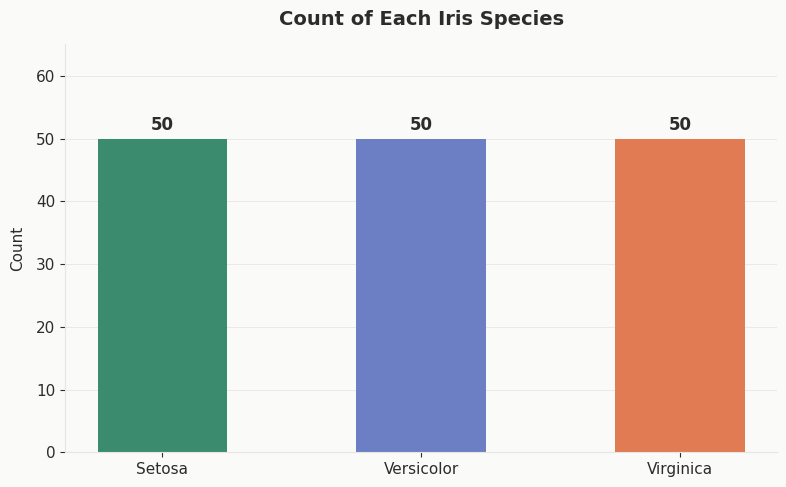

In [5]:
counts = df["Species"].value_counts().reindex(["Setosa","Versicolor","Virginica"])
colors = [PALETTE[s] for s in counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, zorder=2)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=12)

ax.set_title("Count of Each Iris Species")
ax.set_ylabel("Count")
ax.set_ylim(0, 65)
ax.set_xlabel("")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()


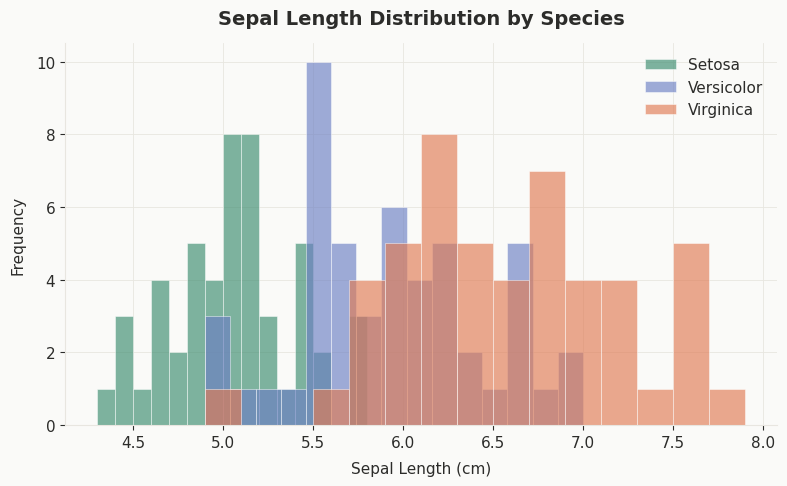

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for sp, col in PALETTE.items():
    subset = df[df["Species"]==sp]["sepal length (cm)"]
    ax.hist(subset, bins=15, alpha=0.65, color=col, edgecolor="white", linewidth=0.5, label=sp, zorder=2)

ax.set_title("Sepal Length Distribution by Species")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Frequency")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


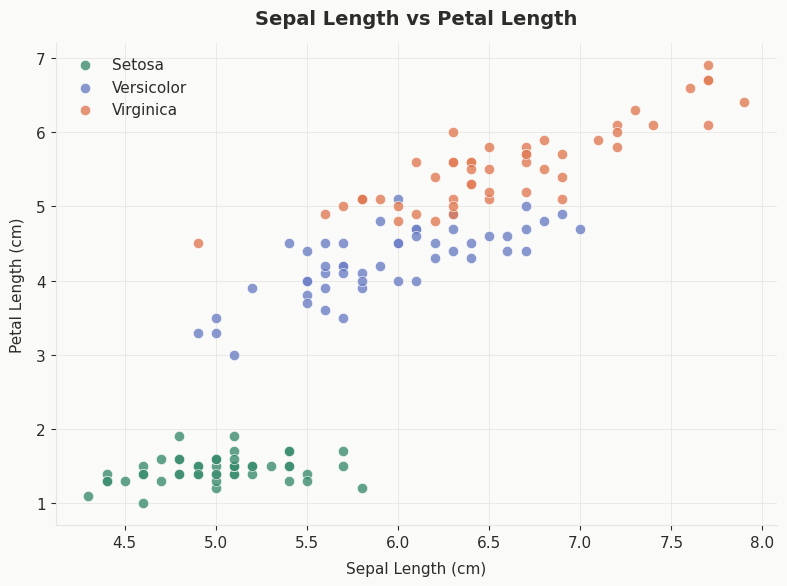

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for sp, col in PALETTE.items():
    sub = df[df["Species"]==sp]
    ax.scatter(sub["sepal length (cm)"], sub["petal length (cm)"],
               color=col, label=sp, alpha=0.8, s=55, edgecolors="white", linewidths=0.5, zorder=3)

ax.set_title("Sepal Length vs Petal Length")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


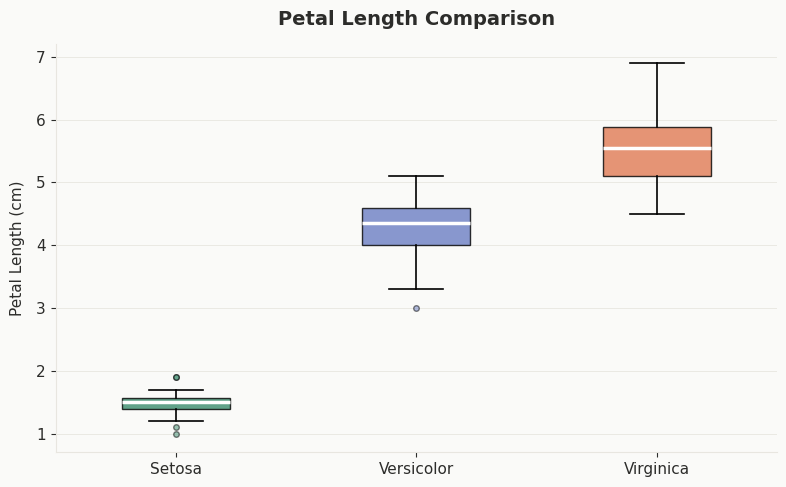

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

species_order = ["Setosa", "Versicolor", "Virginica"]
data_by_sp = [df[df["Species"]==sp]["petal length (cm)"].values for sp in species_order]
bp = ax.boxplot(data_by_sp, patch_artist=True, notch=False, widths=0.45,
                medianprops=dict(color="white", linewidth=2.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))

for patch, sp in zip(bp["boxes"], species_order):
    patch.set_facecolor(PALETTE[sp])
    patch.set_alpha(0.8)
for flier, sp in zip(bp["fliers"], species_order):
    flier.set_markerfacecolor(PALETTE[sp])

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(species_order)
ax.set_title("Petal Length Comparison")
ax.set_ylabel("Petal Length (cm)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()


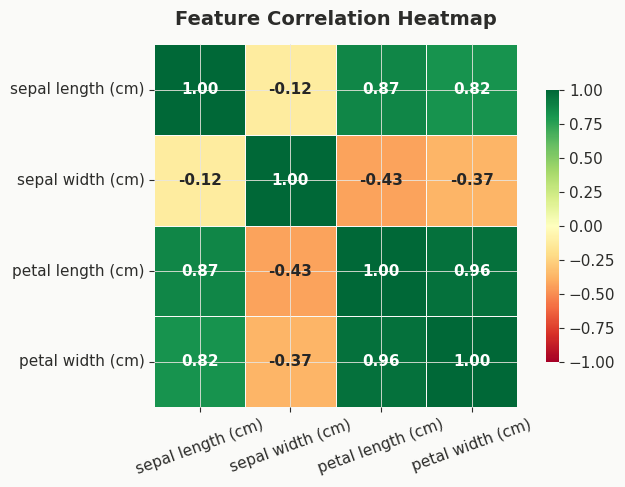

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df.drop(columns="Species").corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor=BG,
            annot_kws={"size":11, "weight":"bold"},
            square=True, ax=ax, cbar_kws={"shrink":0.75})

ax.set_title("Feature Correlation Heatmap")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.show()


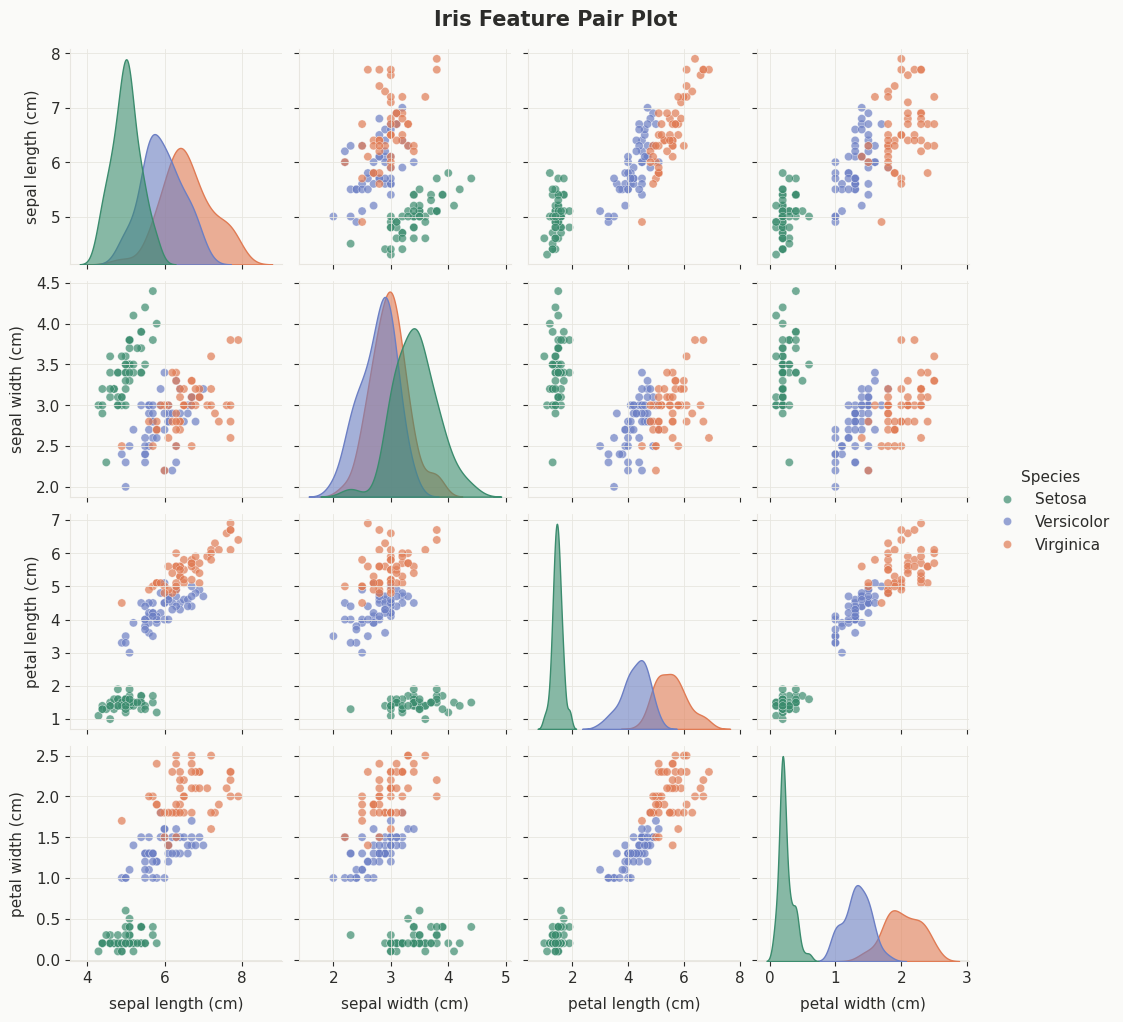

In [10]:
g = sns.pairplot(
    df,
    hue="Species",
    palette=PALETTE,
    diag_kind="kde",
    plot_kws=dict(alpha=0.7, s=35, edgecolor="white", linewidth=0.3),
    diag_kws=dict(alpha=0.6),
    corner=False
)
g.figure.suptitle("Iris Feature Pair Plot", y=1.02, fontsize=15, fontweight="bold")
plt.show()
